# IE 302 Economics for Engineers - Final Project
**Industry:** Food (Animal Products & Dairy)
**Companies:** PINAR SUT MAMULLERI SANAYII & PINAR ENTEGRE ET VE YEM SANAYII

---

## 1. Industry Review

The food and beverage sector, particularly the animal products and dairy segment, is one of the most vital and resilient industries in Turkey. It plays a critical role in both the domestic economy and the country's export dynamics. This project focuses on two major players operating within this sector: Pınar Süt (dairy products) and Pınar Et (meat and integrated animal products). 

**Sector Dynamics and Supply Chain**
The Turkish dairy and meat industry operates within a highly complex and time-sensitive supply chain. Unlike traditional manufacturing industries where raw materials and finished goods can be stored indefinitely, animal products are highly perishable. This fundamental characteristic necessitates a robust cold chain infrastructure and fast inventory turnover. Efficient logistics, temperature-controlled warehousing, and rapid distribution networks are not just cost-saving measures but essential requirements for survival and regulatory compliance. Consequently, inventory management in this sector is fundamentally different from industries like automotive or electronics. High inventory levels often lead to spoilage, obsolescence, and massive financial losses rather than acting as a buffer against supply chain disruptions.

**Economic Importance and Market Structure**
Turkey is a major regional agricultural hub, and its food manufacturing industry is heavily integrated with the local farming sector. Companies like Pınar rely on thousands of local farmers and cooperatives to source raw milk and livestock. This creates a strong macroeconomic footprint, generating significant employment and driving rural development. However, this reliance on local agriculture also exposes the industry to specific macroeconomic risks, such as fluctuations in feed prices, exchange rate volatility (which affects imported inputs like vaccines and specialized equipment), and climatic variations. 

**Financial Characteristics**
From a financial engineering perspective, companies in the perishable food sector typically operate with lower profit margins on individual items but compensate with high sales volumes and rapid asset turnover. Working capital management is heavily scrutinized. Accounts receivable and payable must be optimized to ensure continuous liquidity, as cash flow cycles are continuous and fast-paced. Furthermore, fixed asset investments (Property, Plant, and Equipment - PPE) tend to be high due to the necessity of acquiring advanced pasteurization plants, automated slaughterhouses, and specialized packaging machinery to ensure global food safety standards.

In conclusion, analyzing the relationship between inventory levels and profitability (Return on Assets) in the Turkish meat and dairy sector requires understanding these structural constraints. While theoretical models suggest an "optimal" inventory level where holding benefits maximize returns, the perishable nature of these products might skew this relationship, forcing companies to adopt a "Just-in-Time" approach where minimizing inventory is constantly prioritized over accumulating it.

## 2. Optimum Inventory

To examine the relationship between firm performance and inventory levels, we estimate a quadratic regression model that allows for a non-linear (inverted U-shaped) effect of inventory[cite: 2]:

$$ROA_i = \beta_0 + \beta_1 Inventory_i + \beta_2 Inventory_i^2 + \beta_3 Cash_i + \beta_4 WC_i + \beta_5 PPE_i + \beta_6 Debt_i + \varepsilon_i$$

where $i$ indexes the firm observations[cite: 2].

The quadratic specification is essential, as it captures the trade-off between the benefits of holding inventory (e.g., avoiding stockouts) and its costs (e.g., holding and obsolescence costs). A positive $\beta_1$ and negative $\beta_2$ indicate an optimal inventory level[cite: 2].

**Variables:**
*   **Dependent Variable:**
    *   $ROA$: Return on Assets, calculated as net profit divided by total assets[cite: 2].
*   **Key Independent Variables:**
    *   $Inventory$: Total inventory divided by total assets[cite: 2].
    *   $Inventory^2$: Square of the inventory ratio, included to test for non-linearity[cite: 2].
*   **Control Variables:**
    *   $Cash$: Cash and cash equivalents scaled by total assets[cite: 2].
    *   $WC$: Working capital ratio[cite: 2].
    *   $PPE$: Property, plant, and equipment scaled by total assets[cite: 2].
    *   $Debt$: Total debt divided by total assets[cite: 2].

### Optimal Inventory Level
Given the quadratic structure, the optimal inventory ratio is obtained by taking the first derivative of the estimated function with respect to inventory and setting it equal to zero[cite: 2]:

$$x^* = -\frac{\beta_1}{2\beta_2}$$

In [1]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the dataset (Make sure the excel file is in the same folder as the jupyter notebook)
file_path = r"C:\Users\tajem\Quadratic regression\IE 302 Data.csv"
df = pd.read_csv(file_path)
# Ensure correct column naming and clean potential trailing spaces
df.columns = df.columns.str.strip()

# Create sub-datasets for our two specific companies
pinar_sut = df[df['Company Name'].str.contains('PINAR SUT', case=False, na=False)].copy()
pinar_et = df[df['Company Name'].str.contains('PINAR ENTEGRE ET', case=False, na=False)].copy()

# Variables list based on the project requirements
features = ['Cash', 'wc', 'Inventory', 'Inventory^2', 'PPE', 'Debt']
target = 'ROA'

# Drop rows with missing values in our features of interest to ensure clean regression
pinar_sut = pinar_sut.dropna(subset=features + [target])
pinar_et = pinar_et.dropna(subset=features + [target])

print(f"Data for PINAR SUT loaded: {pinar_sut.shape[0]} observations.")
print(f"Data for PINAR ET loaded: {pinar_et.shape[0]} observations.")

Data for PINAR SUT loaded: 20 observations.
Data for PINAR ET loaded: 22 observations.


In [2]:
# 3.1 Empirical Evidence: PINAR SUT
# Define independent variables (adding constant)
X_sut = sm.add_constant(pinar_sut[features])
y_sut = pinar_sut[target]

# Fit the OLS model
model_sut = sm.OLS(y_sut, X_sut).fit()

# Print the summary
print("Regression Results for PINAR SUT MAMULLERI SANAYII")
print(model_sut.summary())

Regression Results for PINAR SUT MAMULLERI SANAYII
                            OLS Regression Results                            
Dep. Variable:                    ROA   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     14.80
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.91e-05
Time:                        17:00:23   Log-Likelihood:                 52.777
No. Observations:                  20   AIC:                            -91.55
Df Residuals:                      13   BIC:                            -84.58
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

### 3.1 Empirical Evidence: PINAR SUT MAMULLERI SANAYII

This section analyzes the determinants of firm performance for Pınar Süt using a quadratic regression model where Return on Assets (ROA) is explained by inventory intensity and key financial control variables.

**Model Fit and Overall Significance**
The regression results indicate a **very strong model fit**, with an $R^2 = 0.8723$, implying that approximately **87.2%** of the variation in ROA is explained by the included variables. The overall model is highly statistically significant, as indicated by the F-statistic ($F = 14.80$, $p < 0.001$). This provides strong evidence that the selected financial variables jointly explain the profitability of the firm.

**Evaluation of Coefficients**
*   **Inventory and Non-linearity:** 
    *   $Inventory$: $\beta_1 = 1.5202$, $p = 0.614$
    *   $Inventory^2$: $\beta_2 = -6.1074$, $p = 0.680$
    Both coefficients are **statistically insignificant**. Although the signs (positive linear, negative quadratic) theoretically point toward an inverted U-shape, the high p-values indicate that inventory levels do not have a meaningful or systematic impact on ROA for Pınar Süt. Therefore, there is **no empirical support for an optimal inventory level** in this case.

*   **Control Variables:**
    *   **Working Capital (WC):** $\beta = 0.4714$, $p = 0.050$. Statistically significant and positive. This suggests that efficient management of short-term liquidity and maintaining positive working capital directly enhances profitability in the dairy sector.
    *   **Cash, PPE, and Debt:** These variables do not show statistical significance at the 10% level, indicating they are not the primary short-term drivers of ROA variations for this specific firm.

In [3]:
# 3.2 Empirical Evidence: PINAR ET
# Define independent variables (adding constant)
X_et = sm.add_constant(pinar_et[features])
y_et = pinar_et[target]

# Fit the OLS model
model_et = sm.OLS(y_et, X_et).fit()

# Print the summary
print("Regression Results for PINAR ENTEGRE ET VE YEM SANAYII")
print(model_et.summary())

Regression Results for PINAR ENTEGRE ET VE YEM SANAYII
                            OLS Regression Results                            
Dep. Variable:                    ROA   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     12.53
Date:                Wed, 06 May 2026   Prob (F-statistic):           4.22e-05
Time:                        17:00:23   Log-Likelihood:                 63.706
No. Observations:                  22   AIC:                            -113.4
Df Residuals:                      15   BIC:                            -105.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

### 3.2 Empirical Evidence: PINAR ENTEGRE ET VE YEM SANAYII

This section evaluates the determinants of firm performance for Pınar Et using the same quadratic regression framework.

**Model Fit and Overall Significance**
The model demonstrates a **strong fit**, with an $R^2 = 0.8337$, suggesting that **83.3%** of the variation in ROA is explained by the model. The overall regression is statistically significant ($F = 12.53$, $p < 0.001$), confirming the relevance of the selected variables.

**Evaluation of Coefficients**
*   **Inventory and Non-linearity:**
    *   $Inventory$: $\beta_1 = -2.4359$, $p = 0.159$
    *   $Inventory^2$: $\beta_2 = 14.3009$, $p = 0.169$
    Similar to Pınar Süt, both inventory coefficients are **statistically insignificant**. The quadratic inventory model is not supported, and the concept of an optimal inventory level is not applicable.

*   **Control Variables:**
    *   **Debt:** $\beta = 0.5331$, $p < 0.001$. Strong positive and highly significant effect. This indicates that leverage is a major driver of profitability for Pınar Et, likely due to the effective use of external financing for operations or tax shield benefits.
    *   **PPE:** $\beta = -0.2012$, $p = 0.048$. Statistically significant and negative. Higher fixed asset intensity (like heavy machinery for meat processing) is associated with lower short-term profitability, possibly due to high depreciation costs.
    *   **Working Capital (WC):** $\beta = -0.3000$, $p = 0.041$. Significant and negative, contrasting with the dairy division, suggesting that excessive short-term assets tied up in operations might be dragging down returns in the meat division.

### 3.3 Comparison and Conclusion

The empirical analysis of Pınar Süt and Pınar Et reveals a consistent and fascinating structural reality about the perishable food industry (dairy and meat). 

For both companies, the quadratic specification fails to identify any optimal inventory level. The inventory coefficients were statistically insignificant across both models. This finding sharply contrasts with traditional manufacturing industries (such as automotive or electronics) where inventory optimization is a critical strategic lever. In the animal products sector, items are highly perishable and operate on a fast-moving, "Just-in-Time" distribution model. Firms in this sector do not have the luxury of strategically accumulating or holding inventory to maximize returns; instead, their primary objective is to clear inventory as rapidly as possible to avoid spoilage. Therefore, variations in the inventory-to-asset ratio do not systematically drive profitability.

However, the drivers of profitability diverge in their financial structures. Pınar Süt’s performance is positively driven by Working Capital efficiency, highlighting the importance of smooth short-term cash conversion cycles in the fast-moving dairy business. Conversely, Pınar Et is heavily influenced by capital structure decisions; it exhibits a strong positive relationship with Debt (leveraging external finance) and a negative relationship with Property, Plant, and Equipment (PPE), reflecting the heavy depreciation burden of meat processing facilities.

Overall, the comparison concludes that while the quadratic optimum inventory theory holds significant value in durable goods sectors, profitability in the perishable food and beverage sector is shaped by rapid cash conversion, leverage efficiency, and capital allocation rather than strategic inventory holding.

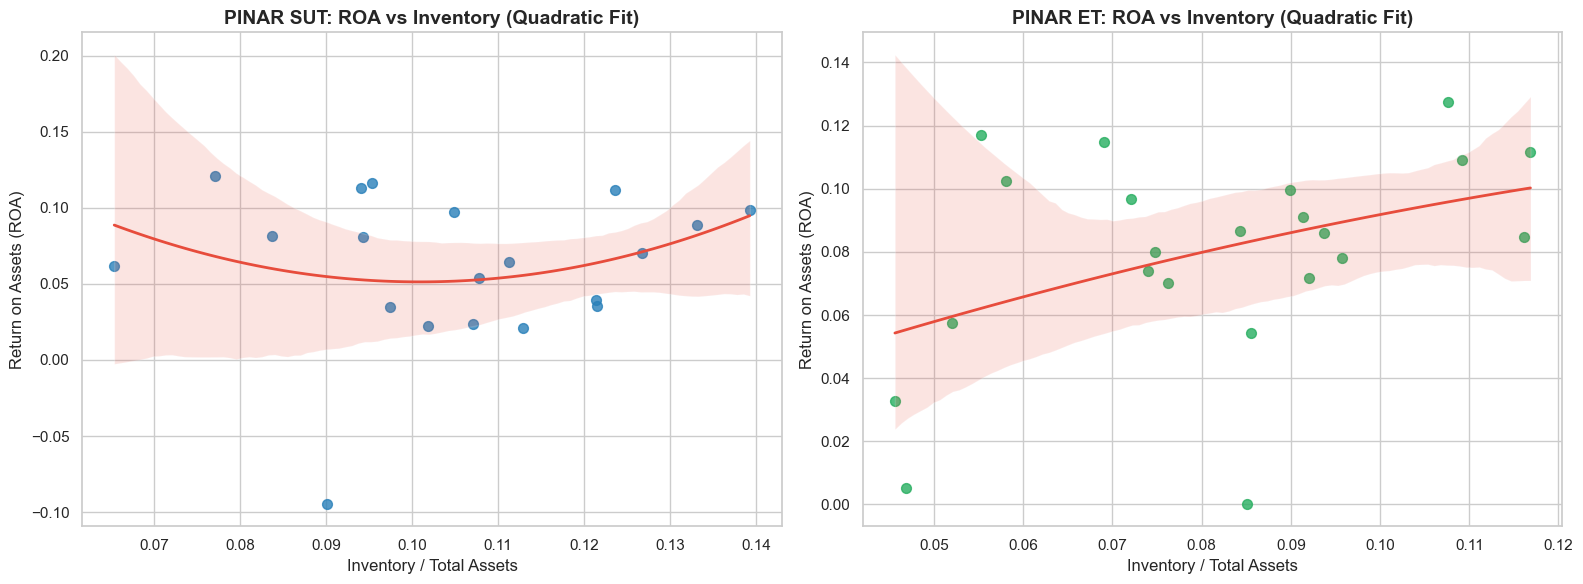

In [4]:
# 4. Data Visualization: ROA vs Inventory
import matplotlib.pyplot as plt

# Set up the figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for PINAR SUT (Dairy)
sns.regplot(x='Inventory', y='ROA', data=pinar_sut, order=2, ax=axes[0], 
            scatter_kws={'color':'#2980b9', 's':50}, line_kws={'color':'#e74c3c', 'lw':2})
axes[0].set_title('PINAR SUT: ROA vs Inventory (Quadratic Fit)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Inventory / Total Assets', fontsize=12)
axes[0].set_ylabel('Return on Assets (ROA)', fontsize=12)

# Plot for PINAR ET (Meat)
sns.regplot(x='Inventory', y='ROA', data=pinar_et, order=2, ax=axes[1], 
            scatter_kws={'color':'#27ae60', 's':50}, line_kws={'color':'#e74c3c', 'lw':2})
axes[1].set_title('PINAR ET: ROA vs Inventory (Quadratic Fit)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Inventory / Total Assets', fontsize=12)
axes[1].set_ylabel('Return on Assets (ROA)', fontsize=12)

# Display the plots
plt.tight_layout()
plt.show()

### Visual Interpretation

The scatter plots above, fitted with a quadratic regression line (red curve), visually reinforce our statistical findings. 

If an "Optimal Inventory Level" existed, we would expect to see a distinct, statistically significant inverted U-shape curve, where ROA peaks at a specific inventory ratio and declines thereafter. However, as illustrated:
1. **Pınar Süt (Left):** The data points are highly dispersed along the inventory axis, and the fitted curve is nearly flat/inconclusive, confirming the lack of a systemic relationship.
2. **Pınar Et (Right):** The curve actually trends slightly upwards at the extremes (a regular U-shape rather than an inverted one), but as proven by the high p-values in our regression summary, this curve is not statistically significant.

This visual evidence solidifies our conclusion: in the highly perishable animal products sector, short-term liquidity (Working Capital) and long-term capital structure (Debt/PPE) overshadow inventory ratios in determining profitability.

In [6]:
# تحويل الدفتر إلى Word باستخدام pandoc (عبر أداة nbconvert) وحفظه في المسار المطلوب
!pandoc "Quadratic regression.ipynb" -s -o "C:\Users\tajem\Quadratic regression\Final_Project.docx"

'pandoc' is not recognized as an internal or external command,
operable program or batch file.
